In [3]:
## Get the measurements for all of the meshes

import pandas as pd

mesh_data = pd.DataFrame(columns=['meshID', 'AR1', 'AR2', 'Length', 'Starting PA'])

mesh_data['meshID'] = ['mesh_1_2', 'mesh_1_3', 'mesh_1_4', 'mesh_1_5', 'mesh_1_6', 'mesh_1_8', 'mesh_2_1', 'mesh_2_6a', 'mesh_2_6b', 'mesh_2_7a', 'mesh_3_1', 'mesh_3_2', 'mesh_3_3']

## Add the aspect ratios to the data frame

mesh_1_2 = [[15.8, 9.3],[16.6, 11.1]]
mesh_1_3 = [[16.1, 10.8],[16.2, 10.1]]
mesh_1_4 = [[15.6, 11.2],[13.8, 11.6]]
mesh_1_5 = [[18.1, 12.5], [17.4, 11.5]]
mesh_1_6 = [[16.3, 11.6],[15.2, 12.4]]
mesh_1_8 = [[14.3, 11.5], [15.5, 11.3]]
mesh_2_1 = [[13.4, 10.2], [13.2, 9.3]]
mesh_2_3 = [[13.6, 7.1],[15.8, 7.9]] ## Issues?
##mesh_2_4 ## Issue
mesh_2_6a = [[17.0, 10.8],[16.9, 10.2]]
mesh_2_6b = [[16.2, 12.6],[15.6, 10.8]] ## Odd cross section
mesh_2_7a = [[13.9, 10.5], [13.7, 11.6]]
mesh_3_1 = [[14.6, 10.9], [14.6, 11.1]]
mesh_3_2 = [[17.3, 12.8],[17.3, 12.3]]
mesh_3_3 = [[17.9, 13.0],[17.2, 11.2]]

mesh_data['AR1'] = [mesh_1_2[0][0]/mesh_1_2[0][1], mesh_1_3[0][0]/mesh_1_3[0][1], mesh_1_4[0][0]/mesh_1_4[0][1], mesh_1_5[0][0]/mesh_1_5[0][1], mesh_1_6[0][0]/mesh_1_6[0][1], mesh_1_8[0][0]/mesh_1_8[0][1], mesh_2_1[0][0]/mesh_2_1[0][1], mesh_2_6a[0][0]/mesh_2_6a[0][1], mesh_2_6b[0][0]/mesh_2_6b[0][1], mesh_2_7a[0][0]/mesh_2_7a[0][1], mesh_3_1[0][0]/mesh_3_1[0][1], mesh_3_2[0][0]/mesh_3_2[0][1], mesh_3_3[0][0]/mesh_3_3[0][1]]
mesh_data['AR2'] = [mesh_1_2[1][0]/mesh_1_2[1][1], mesh_1_3[1][0]/mesh_1_3[1][1], mesh_1_4[1][0]/mesh_1_4[1][1], mesh_1_5[1][0]/mesh_1_5[1][1], mesh_1_6[1][0]/mesh_1_6[1][1], mesh_1_8[1][0]/mesh_1_8[1][1], mesh_2_1[1][0]/mesh_2_1[1][1], mesh_2_6a[1][0]/mesh_2_6a[1][1], mesh_2_6b[1][0]/mesh_2_6b[1][1], mesh_2_7a[1][0]/mesh_2_7a[1][1], mesh_3_1[1][0]/mesh_3_1[1][1], mesh_3_2[1][0]/mesh_3_2[1][1], mesh_3_3[1][0]/mesh_3_3[1][1]]

mesh_data

,meshID,AR1,AR2,Length,Starting PA
0,mesh_1_2,1.698925,1.495495,NaN,NaN
1,mesh_1_3,1.490741,1.603960,NaN,NaN
2,mesh_1_4,1.392857,1.189655,NaN,NaN
3,mesh_1_5,1.448000,1.513043,NaN,NaN
4,mesh_1_6,1.405172,1.225806,NaN,NaN
5,mesh_1_8,1.243478,1.371681,NaN,NaN
6,mesh_2_1,1.313725,1.419355,NaN,NaN
7,mesh_2_6a,1.574074,1.656863,NaN,NaN
8,mesh_2_6b,1.285714,1.444444,NaN,NaN
9,mesh_2_7a,1.323810,1.181034,NaN,NaN


In [4]:
def create_sliced_torus(R, r, num_theta, num_phi, slice_width=1.0, export_steps=False):
    """
    Create a torus with a vertical slice removed from the middle.
    
    Parameters:
    - R: Major radius
    - r: Minor radius
    - num_theta: Number of points around major circumference
    - num_phi: Number of points around minor circumference
    - slice_width: Width of vertical slice to remove
    
    Returns:
    - Trimesh object of the sliced torus
    """
    import numpy as np
    import trimesh
    
    # Calculate slice parameters
    half_width = slice_width / 2.0
    print(f"Slice width: {slice_width}, half-width: {half_width}")
    
    # STEP 1: Generate angles for the original torus
    all_theta = np.linspace(0, 2*np.pi, num_theta, endpoint=False)
    
    # STEP 2: Filter out angles in the vertical slice
    x_coords = R * np.cos(all_theta)
    keep_mask = np.logical_or(x_coords < -half_width, x_coords > half_width)
    kept_theta = all_theta[keep_mask]
    
    # Sort the angles for proper ordering
    sort_idx = np.argsort(kept_theta)
    sorted_theta = kept_theta[sort_idx]
    
    # Evenly space the kept angles around a full circle
    new_theta = np.linspace(0, 2*np.pi, len(sorted_theta), endpoint=False)
    
    # STEP 3: Calculate oval parameters
    oval_width = 2*(R - slice_width/2)
    oval_height = 2*R
    
    # Semi-major axes
    a = oval_width/2
    b = oval_height/2
    
    # STEP 4: Generate vertices with circular cross-section
    vertices = []
    vertex_indices = {}
    next_idx = 0
    
    for i, theta in enumerate(new_theta):
        for j in range(num_phi):
            phi = 2 * np.pi * j / num_phi
            
            # Regular circular cross-section
            x_local = r * np.cos(phi)
            z_local = r * np.sin(phi)
            
            # Position in 3D space
            x = (a + x_local) * np.cos(theta)
            y = (b + x_local) * np.sin(theta)
            z = z_local
            
            vertices.append([x, y, z])
            vertex_indices[(i, j)] = next_idx
            next_idx += 1
    
    # STEP 5: Generate faces
    faces = []
    
    # Create faces between adjacent theta values
    for i in range(len(new_theta) - 1):
        i_next = i + 1
        for j in range(num_phi):
            j_next = (j + 1) % num_phi
            
            v00 = vertex_indices[(i, j)]
            v01 = vertex_indices[(i, j_next)]
            v10 = vertex_indices[(i_next, j)]
            v11 = vertex_indices[(i_next, j_next)]
            
            faces.append([v00, v10, v11])
            faces.append([v00, v11, v01])
    
    # Connect the last theta value back to the first
    i = len(new_theta) - 1
    i_next = 0
    for j in range(num_phi):
        j_next = (j + 1) % num_phi
        
        v00 = vertex_indices[(i, j)]
        v01 = vertex_indices[(i, j_next)]
        v10 = vertex_indices[(i_next, j)]
        v11 = vertex_indices[(i_next, j_next)]
        
        faces.append([v00, v10, v11])
        faces.append([v00, v11, v01])
    
    # Create the mesh
    mesh = trimesh.Trimesh(vertices=np.array(vertices), faces=np.array(faces))
    
    if export_steps:
        filename = f"sliced_torus_width_{slice_width}.ply"
        mesh.export(filename)
        print(f"Exported mesh as '{filename}'")
        
        # Create visualization
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D
        
        fig = plt.figure(figsize=(15, 10))
        
        # Top view of full mesh
        ax1 = fig.add_subplot(221)
        ax1.set_title("Top View - Sliced Torus")
        verts = np.array(vertices)
        ax1.scatter(verts[:, 0], verts[:, 1], c='blue', s=1, alpha=0.3)
        ax1.set_aspect('equal')
        ax1.grid(True)
        
        # Side view
        ax2 = fig.add_subplot(222)
        ax2.set_title("Front View")
        ax2.scatter(verts[:, 0], verts[:, 2], c='blue', s=1, alpha=0.3)
        ax2.set_aspect('equal')
        ax2.grid(True)
        
        # Cross-section shape
        ax3 = fig.add_subplot(223)
        ax3.set_title("Cross-Section Shape")
        
        # Draw circular cross-section
        phi = np.linspace(0, 2*np.pi, 100)
        x_cs = r * np.cos(phi)
        z_cs = r * np.sin(phi)
        ax3.plot(x_cs, z_cs, color='blue', label="Circular cross-section")
        
        ax3.set_aspect('equal')
        ax3.grid(True)
        ax3.legend(fontsize=8)
        
        # 3D view
        ax4 = fig.add_subplot(224, projection='3d')
        ax4.set_title("3D View")
        
        # Plot every nth vertex for clarity
        skip = max(1, len(vertices) // 2000)
        ax4.scatter(verts[::skip, 0], verts[::skip, 1], verts[::skip, 2], 
                   c='blue', s=5, alpha=0.5)
        
        ax4.set_xlabel('X')
        ax4.set_ylabel('Y')
        ax4.set_zlabel('Z')
        ax4.view_init(elev=30, azim=60)
        
        plt.tight_layout()
        plt.savefig(f"sliced_torus_viz_{slice_width}.png", dpi=200)
        print(f"Saved visualization as 'sliced_torus_viz_{slice_width}.png'")
    
    return mesh

Slice width: 12.0, half-width: 6.0
Exported mesh as 'sliced_torus_width_12.0.ply'
Saved visualization as 'sliced_torus_viz_12.0.png'


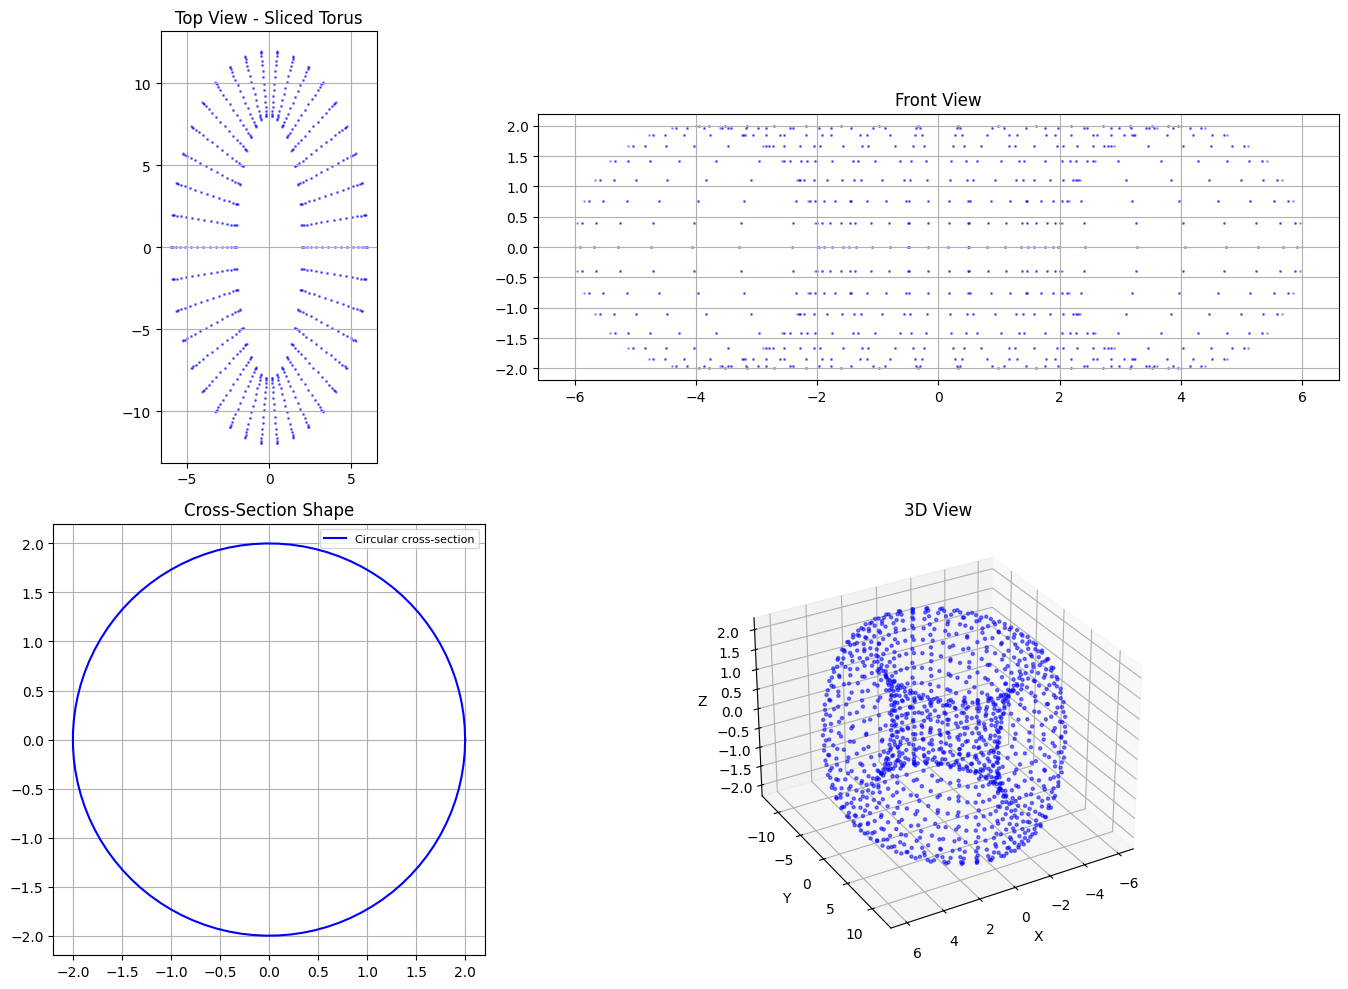

In [8]:
mesh = create_sliced_torus(R=10, r=2, num_theta=64, num_phi=32, slice_width=12.0, export_steps=True)